# Configuraciones del doble péndulo

In [ ]:
import numpy as np
import rclpy
from rclpy.node import Node
from sensor_msgs.msg import JointState
import time

# Preparo el nodo de ros2 para escribir el valor de las juntas
if not rclpy.ok():
    rclpy.init()
    ros2node = Node('test_configs')
    joint_publisher = ros2node.create_publisher(JointState, '/joint_states', 10)
    joint_state = JointState()
    joint_state.name = ['joint1', 'joint2']

def moverRobot(q):
    q = np.atleast_2d(q)
    for i in range(0,q.shape[0]):
        joint_state.header.stamp = ros2node.get_clock().now().to_msg()  # Marca de tiempo
        joint_state.position = list(q[i,:])  # Asignar las posiciones de los joints
        joint_publisher.publish(joint_state)  # Publicar el mensaje        
        time.sleep(0.01)

In [ ]:
def fk_dp(q, a=[0.2,0.2]):
    """
    Cinemática directa de un Doble Pendulo.

    Parámetros
    ----------
    q : array-like (2,)
        Variables articulares [q1, q2]
    a : array-like (2,)
        Longitudes [a1, a2]

    Retorna
    -------
    pos : array-like (2,)
        Vector de posición alcanzada
    conf : int
        Configuración (signo de q2)
    """

    q = np.asarray(q)
    a = np.asarray(a)

    A10 = np.array([
        [np.cos(q[0]), -np.sin(q[0]), 0, a[0]*np.cos(q[0])],
        [np.sin(q[0]),  np.cos(q[0]), 0, a[0]*np.sin(q[0])],
        [0,             0,            1, 0],
        [0,             0,            0, 1]
    ])

    A21 = np.array([
        [np.cos(q[1]), -np.sin(q[1]), 0, a[1]*np.cos(q[1])],
        [np.sin(q[1]),  np.cos(q[1]), 0, a[1]*np.sin(q[1])],
        [0,             0,            1, 0],
        [0,             0,            0, 1]
    ])

    # Producto homogéneo completo (producto matricial)
    POSE = A10 @ A21 

    # Configuración del codo (necesaria para la IK)
    conf = np.sign(q[1])
    if conf == 0:
        conf = 1

    return POSE.t[0:1], int(conf)


def ik_dp(pos, conf, q1_ini=0, a=[0.2,0.2]):
    """
    Cinemática inversa de un SCARA.

    Parámetros
    ----------
    pos : array-like (2,)
        Posición deseada de la terna 2
    conf : int
        Configuración (+1 o -1)
    q0_sing : double
        Valor del eje 1 en el caso de singularidad interna
    a : array-like (2,)
        Longitudes [a1, a2]

    Retorna
    -------
    q : ndarray (2,)
        Variables articulares [q1, q2]
    status : int
        0 = OK, -1 = no alcanzable
    """

    a = np.asarray(a)
    q = np.zeros(2)

    px = pos[0]
    py = pos[1]

    # Alcanzabilidad: distancia a la posición deseada vs radio máximo
    if (px**2 + py**2) > (a[0] + a[1])**2:
        print("El punto no es alcanzable (afuera)")
        return q, -1
    if (px**2 + py**2) < (a[0] - a[1])**2:
        print("El punto no es alcanzable (adentro)")
        return q, -1

    # Ley de cosenos para q2: crítico identificar las dos soluciones
    c2 = (px**2 + py**2 - (a[0]**2 + a[1]**2)) / (2 * a[0] * a[1])

    # Protección numérica (evita errores en sqrt cuando c2 > 1 por flota)
    c2 = np.clip(c2, -1.0, 1.0)

    s2 = conf * np.sqrt(1 - c2**2)
    q[1] = np.arctan2(s2, c2)

    # Cálculo de q1: singularidad interna cuando el punto está en el origen
    denom = px**2 + py**2
    if np.linalg.norm(denom) < 1e-5:
        q[0] = q1_ini  # Singularidad: cualquier q1 alcanza el origen
    else:
        s1 = (a[1]*(py*c2 - px*s2) + a[0]*py) / denom
        c1 = (a[1]*(py*s2 + px*c2) + a[0]*px) / denom
        q[0] = np.arctan2(s1, c1)  # atan2 evita ambigüedad en cuadrantes

    return q, 0


In [26]:
pos = np.r_[0.2, 0]

q_c1, _ = ik_dp(pos, conf=1)
q_c2, _ = ik_dp(pos, conf=-1)

print("Configuración codo abajo: q =", q_c1)
print("Configuración codo arriba: q =", q_c2)

Configuración codo abajo: q = [-1.04719755  2.0943951 ]
Configuración codo arriba: q = [ 1.04719755 -2.0943951 ]


In [ ]:
# Ver robot en configuración codo abajo
# Recordar desactivar cualquier nodo que publique en /joint_states para evitar conflictos
moverRobot(q_c1)

In [ ]:
# Ver robot en configuración codo arriba
moverRobot(q_c2)

In [27]:
# Ver animación entre ambas configuraciones
q = np.linspace(q_c1, q_c2, num=500)
moverRobot(q)

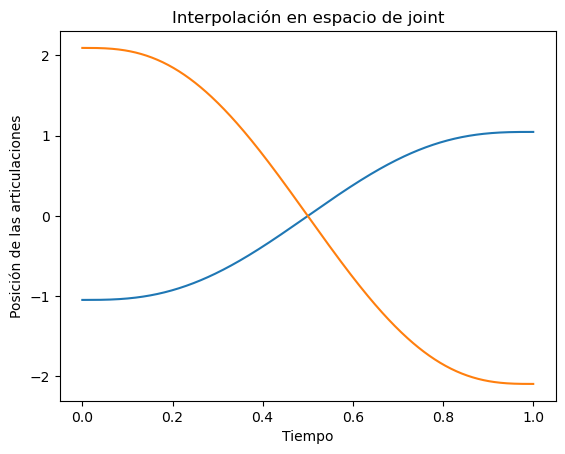

In [31]:
from matplotlib import pyplot as plt

# Una evolución más suave y compatible con robótica real (interpolación en espacio de joint)
t = np.linspace(0, 1, 500)
s = 10*t**3 - 15*t**4 + 6*t**5
q = q_c1 + (q_c2 - q_c1) * s[:, None]

plt.plot(t, q)
plt.xlabel('Tiempo')
plt.ylabel('Posición de las articulaciones')
plt.title('Interpolación en espacio de joint')
moverRobot(q)

# Movimiento en línea recta cerca de singularidad

Se realiza un movimiento en línea recta que pasa muy cerca del origen de la base.
En este robot, el origen constituye una singularidad cuando el largo de los eslabones es el mismo.

En las inmediaciones del origen para que el robot pueda mantener la velocidad de avance, el eje 1 debe desarrollar velocidades inmensas

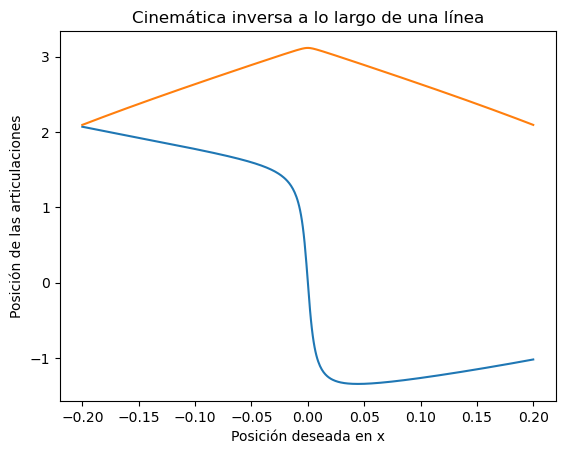

In [50]:
px = np.linspace(-0.2, 0.2, num=500)
pos = np.column_stack((px, np.full_like(px, 0.005)))

q = np.array([
    ik_dp(p, conf=1)[0]
    for p in pos
])

plt.plot(px,q)
plt.xlabel('Posición deseada en x')
plt.ylabel('Posición de las articulaciones')
plt.title('Cinemática inversa a lo largo de una línea')
moverRobot(q)